#### Data Extraction

In [1]:
# Data Extraction.
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
df = pd.read_csv('drive/My Drive/Tufts/Masters Thesis Research/Datasets/vehicles.csv')
df_copy = df.copy()
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [3]:
# Dataset information.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [4]:
# New numeric columns
df['age'] = 2025-df['year']
df['price_per_mileage'] = df['price']/df['odometer']
df['mileage_per_year'] = df['odometer']/df['age']

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 426880 non-null  int64  
 1   url                426880 non-null  object 
 2   region             426880 non-null  object 
 3   region_url         426880 non-null  object 
 4   price              426880 non-null  int64  
 5   year               425675 non-null  float64
 6   manufacturer       409234 non-null  object 
 7   model              421603 non-null  object 
 8   condition          252776 non-null  object 
 9   cylinders          249202 non-null  object 
 10  fuel               423867 non-null  object 
 11  odometer           422480 non-null  float64
 12  title_status       418638 non-null  object 
 13  transmission       424324 non-null  object 
 14  VIN                265838 non-null  object 
 15  drive              296313 non-null  object 
 16  si

In [5]:
# Get missing values across
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


#### Plot Numeric Data, Impute from Median.

['price', 'year', 'odometer', 'lat', 'long', 'age', 'price_per_mileage', 'mileage_per_year']


/tmp/ipython-input-2091105120.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[numeric_column].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-2091105120.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

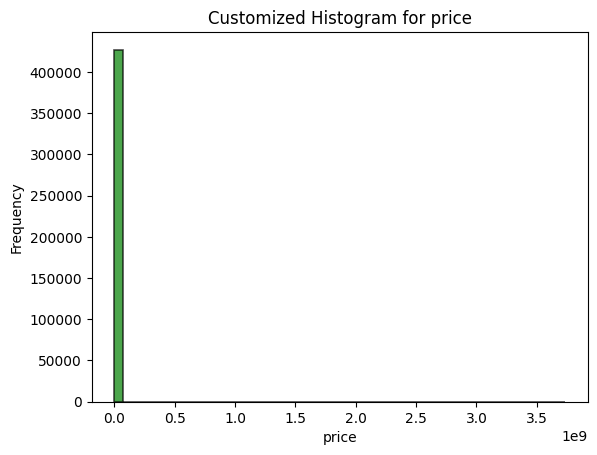

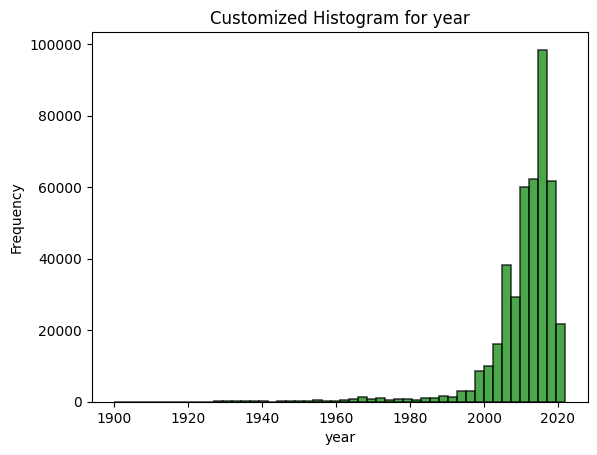

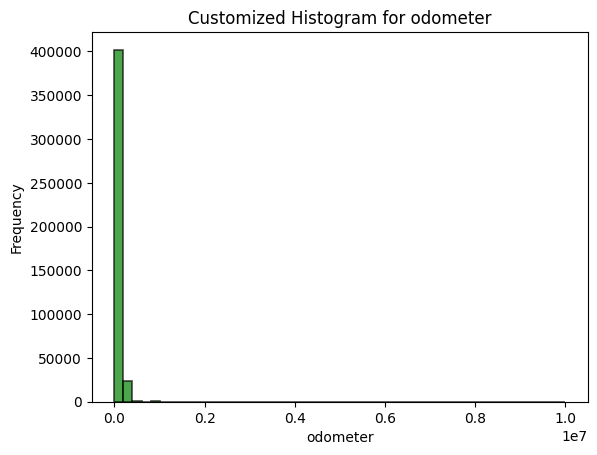

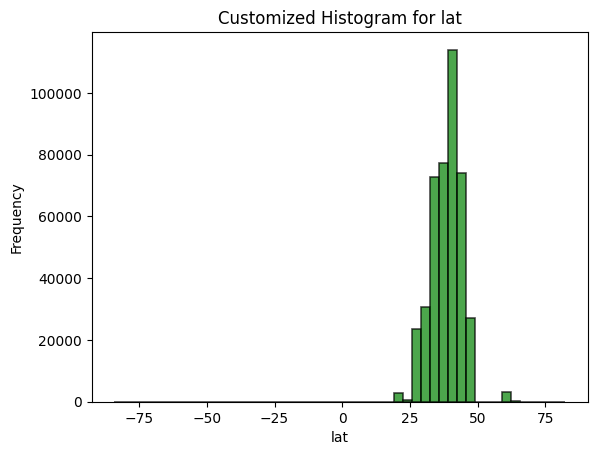

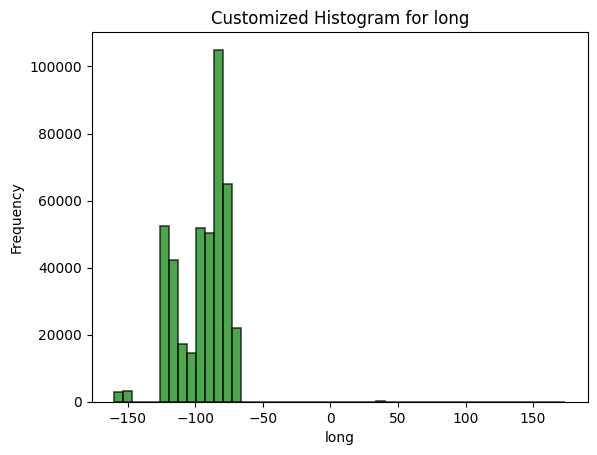

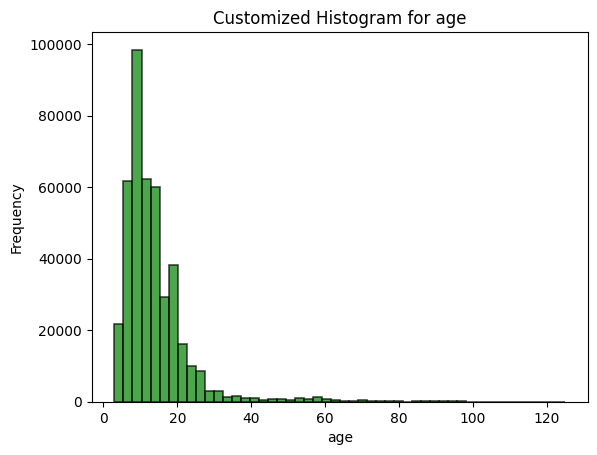

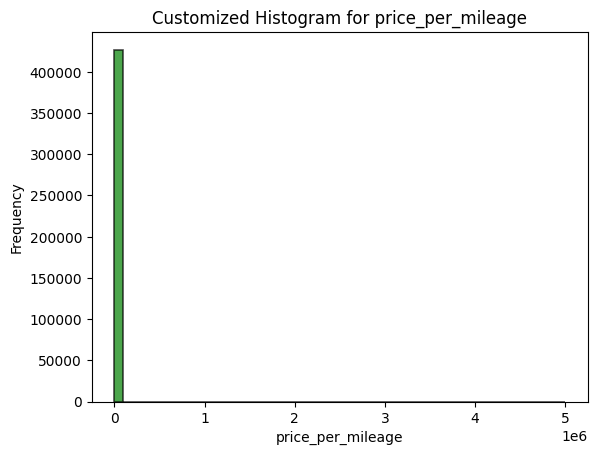

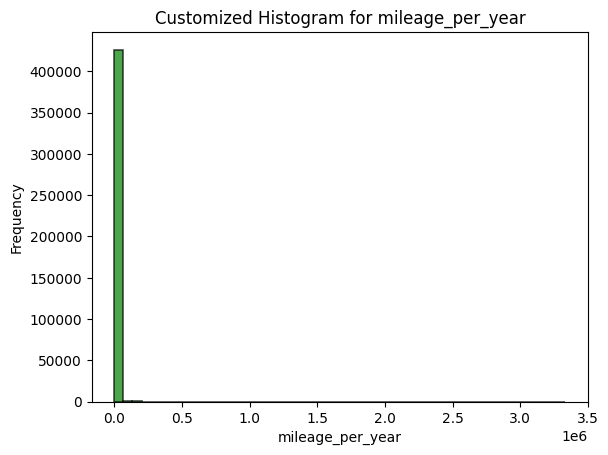

In [6]:
# Handling the missing data.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer

df=df.drop('county', axis=1)
df=df.drop('id', axis=1)

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_columns)

# Impute The Missing Data - Moved before QuantileTransformer
for numeric_column in numeric_columns:
    if numeric_column == 'id':
        continue
    # Replace infinite values that might result from division by zero
    df[numeric_column].replace([np.inf, -np.inf], np.nan, inplace=True)
    df[numeric_column].fillna(df[numeric_column].median(), inplace=True)

# Create histogram for the numeric columns.
for column in numeric_columns:
  if column == 'id':
    continue

  # Create histogram to obtain normal distribution of the numeric variables.
  plt.figure()
  plt.hist(df[column], bins=50, color='green', alpha=0.7, edgecolor='black', linewidth=1.2)
  plt.title(f'Customized Histogram for {df[column].name}')
  plt.xlabel(f'{df[column].name}') # Removed (Transformed)
  plt.ylabel('Frequency')
  plt.show()

In [7]:
# Impute The Missing Data
for numeric_column in numeric_columns:
  if numeric_column == 'id':
    continue

  df[numeric_column].fillna(df[numeric_column].median(), inplace=True)

df.describe()



/tmp/ipython-input-4102822534.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[numeric_column].fillna(df[numeric_column].median(), inplace=True)


,price,year,odometer,lat,long,age,price_per_mileage,mileage_per_year
count,4.268800e+05,426880.000000,4.268800e+05,426880.000000,426880.000000,426880.000000,4.268800e+05,4.268800e+05
mean,7.519903e+04,2011.240173,9.791454e+04,38.504007,-94.651702,13.759827,9.763864e+01,7.312528e+03
std,1.218228e+07,9.439234,2.127801e+05,5.797112,18.240566,9.439234,9.211274e+03,1.612666e+04
min,0.000000e+00,1900.000000,0.000000e+00,-84.122245,-159.827728,3.000000,0.000000e+00,0.000000e+00
25%,5.900000e+03,2008.000000,3.813000e+04,34.757016,-111.907973,8.000000,4.405941e-02,4.017807e+03
50%,1.395000e+04,2013.000000,8.554800e+04,39.150100,-88.432600,12.000000,1.489615e-01,6.785056e+03
75%,2.648575e+04,2017.000000,1.330000e+05,42.350000,-81.030000,17.000000,5.824243e-01,9.404200e+03
max,3.736929e+09,2022.000000,1.000000e+07,82.390818,173.885502,125.000000,5.000000e+06,3.333333e+06


#### Imputing the Categorical Data

In [8]:
from sklearn.impute import SimpleImputer
categorical_columns = df.select_dtypes(include=['object']).columns
primary_columns = ['url', 'region_url', 'image_url', 'VIN']
categorical_columns = [column for column in categorical_columns if column not in primary_columns]

# Create histogram for the numeric columns.
for column in categorical_columns:
  if column == 'id':
    continue

  df[column] = SimpleImputer(strategy='most_frequent').fit_transform(df[column].values.reshape(-1, 1))[:, 0]
  print(df[column].value_counts())






region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64
manufacturer
ford               88631
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln       

#### One Hot Encoding Categorical Data

In [9]:
# One-Hot Encoding
import pandas as pd

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
primary_columns = ['url', 'region_url', 'image_url', 'VIN']
categorical_columns = [column for column in categorical_columns if column not in primary_columns]

# Select categorical columns with up to 10 unique values
columns_to_encode_10_or_less = [col for col in categorical_columns if df[col].nunique() <= 10]

# Identify columns for top 10 most frequent values
columns_for_top_10 = ['manufacturer', 'type', 'region', 'title_status', 'transmission', 'drive', 'condition', 'fuel']
columns_to_encode_top_10 = []

# For all the columns, get up to the 10 most frequent values.
for col in columns_for_top_10:
    if col in categorical_columns:
        top_10_values = df[col].value_counts().nlargest(10).index.tolist()
        # Create new columns for each of the top 10 values
        for value in top_10_values:
            df[f'{col}_{value}'] = (df[col] == value).astype(int)
        columns_to_encode_top_10.append(col)


# Combine the lists of columns to encode
all_columns_to_encode = columns_to_encode_10_or_less + columns_to_encode_top_10

# Perform one-hot encoding on columns with 10 or fewer unique values
df_encoded = pd.get_dummies(df, columns=columns_to_encode_10_or_less, dummy_na=False, dtype=int)

# The top 10 columns have already been created as separate columns with boolean values.
# We can now drop the original 'manufacturer', 'type', 'state', and 'region' columns
df_encoded = df_encoded.drop(columns_for_top_10, axis=1, errors='ignore')


# Display the first few rows of the encoded DataFrame and its info to see the changes
display(df_encoded.head())
display(df_encoded.info())

,url,region_url,price,year,model,odometer,VIN,paint_color,image_url,description,...,transmission_automatic,transmission_manual,transmission_other,drive_4wd,drive_fwd,drive_rwd,size_compact,size_full-size,size_mid-size,size_sub-compact
0,https://prescott.craigslist.org/cto/d/prescott...,https://prescott.craigslist.org,6000,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,1,0,0,1,0,0,0,1,0,0
1,https://fayar.craigslist.org/ctd/d/bentonville...,https://fayar.craigslist.org,11900,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,1,0,0,1,0,0,0,1,0,0
2,https://keys.craigslist.org/cto/d/summerland-k...,https://keys.craigslist.org,21000,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,1,0,0,1,0,0,0,1,0,0
3,https://worcester.craigslist.org/cto/d/west-br...,https://worcester.craigslist.org,1500,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,1,0,0,1,0,0,0,1,0,0
4,https://greensboro.craigslist.org/cto/d/trinit...,https://greensboro.craigslist.org,4900,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,1,0,0,1,0,0,0,1,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Columns: 105 entries, url to size_sub-compact
dtypes: float64(7), int64(89), object(9)
memory usage: 342.0+ MB


None

#### KDS Model Implementation

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class KDS(nn.Module):
    def __init__(
        self,
        num_layers,
        input_size,
        hidden_size,
        penalty,
        accelerate=True,
        train_step=True,
        W=None,
        step=None,
    ):
        super(KDS, self).__init__()

        # hyperparameters
        self.register_buffer("num_layers", torch.tensor(int(num_layers)))
        self.register_buffer("input_size", torch.tensor(int(input_size)))
        self.register_buffer("hidden_size", torch.tensor(int(hidden_size)))
        self.register_buffer("penalty", torch.tensor(float(penalty)))
        self.register_buffer("accelerate", torch.tensor(bool(accelerate)))

        # parameters
        if W is None:
            W = torch.zeros(self.hidden_size, self.input_size)
        self.register_parameter("W", torch.nn.Parameter(W))
        if step is None:
            step = W.svd().S[0] ** -2
        if train_step:
            self.register_parameter("step", torch.nn.Parameter(step))
        else:
            self.register_buffer("step", step)

    def forward(self, y):
        x = self.encode(y)
        y = self.decode(x)
        return y

    def encode(self, y):
        if self.accelerate:
            return self.encode_accelerated(y)
        else:
            return self.encode_basic(y)

    def encode_basic(self, y):
        x = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # 'weight' here is actually distances_sq, used to compute gradient for x.
        distances_sq = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x @ self.W - y) @ self.W.T
            # The penalty here influences the sparsity of x during the encoding process
            grad = grad + distances_sq * self.penalty
            x = self.activate(x - grad * self.step)
        return x

    def encode_accelerated(self, y):
        x_tmp = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        x_old = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # 'weight' here is actually distances_sq, used to compute gradient for x.
        distances_sq = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x_tmp @ self.W - y) @ self.W.T
            # The penalty here influences the sparsity of x during the encoding process
            grad = grad + distances_sq * self.penalty
            x_new = self.activate(x_tmp - grad * self.step)
            x_old, x_tmp = x_new, x_new + layer / (layer + 3) * (x_new - x_old)
        return x_new

    def decode(self, x):
        return x @ self.W

    def activate(self, x):
        m, n = x.shape
        cnt_m = torch.arange(m, device=x.device)
        cnt_n = torch.arange(n, device=x.device)
        u = x.sort(dim=1, descending=True).values
        v = (u.cumsum(dim=1) - 1) / (cnt_n + 1)
        w = v[cnt_m, (u > v).sum(dim=1) - 1]
        return (x - w.view(m, 1)).relu()

In [11]:
# Loss
class LocalDictionaryLoss(torch.nn.Module):
    def __init__(self, penalty):
        super(LocalDictionaryLoss, self).__init__()
        self.penalty = penalty

    def forward(self, A, y, x):
        return self.forward_detailed(A, y, x)[2]

    def forward_detailed(self, A, y, x):
        weight = (y.unsqueeze(1) - A.unsqueeze(0)).pow(2).sum(dim=2)
        a = 0.5 * (y - x @ A).pow(2).sum(dim=1).mean()
        b = (weight * x).sum(dim=1).mean()
        return a, b, a + b * self.penalty

#### Data Preparation


In [12]:
# Preparing the data, extracting the prices.
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def prepare_data(df, feature_cols, test_size=0.3, val_size=0.15):
    """
    Prepare data for training

    Args:
        df: DataFrame with features and price
        feature_cols: List of feature column names
        test_size: Fraction for test set
        val_size: Fraction of train for validation

    Returns:
        Dictionary with train/val/test splits and scaler
    """
    # X will contain features specified in feature_cols
    X = df[feature_cols].values
    print(f"[prepare_data] Shape of X (before split): {X.shape}") # Diagnostic print
    print(f"[prepare_data] X features head (first row): {X[0, :5]}...") # Diagnostic print

    # y is the target price, log1p transformed for prediction
    y = df['price'].values

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, random_state=42
    )

    print(f"X_train min/max BEFORE feature scaling: [{X_train.min():.2f}, {X_train.max():.2f}]")
    # This is more robust to outliers than StandardScaler or MinMaxScaler for non-Gaussian data
    feature_scaler = QuantileTransformer(output_distribution='uniform', random_state=42)
    print(f"Type of feature_scaler: {type(feature_scaler)}")
    X_train = feature_scaler.fit_transform(X_train)
    X_val = feature_scaler.transform(X_val)
    X_test = feature_scaler.transform(X_test)
    print(f"X_train min/max AFTER feature scaling: [{X_train.min():.2f}, {X_train.max():.2f}]")

    price_scaler = QuantileTransformer(output_distribution='uniform', random_state=42)
    y_train_scaled = price_scaler.fit_transform(y_train.reshape(-1, 1))
    y_val_scaled = price_scaler.transform(y_val.reshape(-1, 1))
    y_test_scaled = price_scaler.transform(y_test.reshape(-1, 1))

    print(f"Train: {len(X_train)} samples")
    print(f"Val: {len(X_val)} samples")
    print(f"Test: {len(X_test)} samples")
    print(f"Feature dim: {X_train.shape[1]}")
    # Print transformed price range and stats
    print(f"Transformed Price range (log1p): {y_train_scaled.min():.2f} - {y_train_scaled.max():.2f}")
    print(f"Transformed Price mean (log1p): {y_train_scaled.mean():.2f} \u00b1 {y_train_scaled.std():.2f}")

    print(f"\u2713 Features range: [{X_train.min():.2f}, {X_train.max():.2f}]")
    print(f"\u2713 Prices range: [{y_train_scaled.min():.2f}, {y_train_scaled.max():.2f}]")

    return {
        'X_train': X_train,
        'y_train': y_train_scaled,
        'X_val': X_val,
        'y_val': y_val_scaled,
        'X_test': X_test,
        'y_test': y_test_scaled,
        'feature_scaler': feature_scaler,
        'price_scaler': price_scaler,
        'y_train_raw': y_train,
        'y_val_raw': y_val,
        'y_test_raw': y_test,
    }

epsilon = 1e-6
df_encoded['price_per_mileage'] = df_encoded['price'] / (df_encoded['odometer'] + epsilon)
df_encoded['mileage_per_year'] = df_encoded['odometer'] / (df_encoded['age'] + epsilon)

# --- MODIFIED: feature_columns now explicitly EXCLUDES 'price', 'price_per_mileage', and 'mileage_per_year' ---
feature_columns = [col for col in df_encoded.select_dtypes(include=['number']).columns if col not in ['price', 'price_per_mileage']]

print(f"Feature columns for KDS model: {feature_columns}")
print(f"Length of feature_columns: {len(feature_columns)}") # Diagnostic print

# Diagnostic: Check df_encoded numeric columns
print("\n--- df_encoded Numeric Column Check ---")
print(f"df_encoded.shape: {df_encoded.shape}")
numeric_cols_in_df_encoded = df_encoded.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns in df_encoded: {len(numeric_cols_in_df_encoded)}")
print(f"Numeric column names (first 5): {numeric_cols_in_df_encoded[:5]}")
print(f"'price' column in df_encoded numeric columns: {'price' in numeric_cols_in_df_encoded}")
print("---------------------------------------")

data_splits = prepare_data(df_encoded, feature_columns)

# Unpack the dictionary into individual variables
X_train = data_splits['X_train']
y_train = data_splits['y_train']
X_val = data_splits['X_val']
y_val = data_splits['y_val']
X_test = data_splits['X_test']
y_test = data_splits['y_test']
feature_scaler = data_splits['feature_scaler']
price_scaler = data_splits['price_scaler']
y_train_raw = data_splits['y_train_raw']
y_val_raw = data_splits['y_val_raw']
y_test_raw = data_splits['y_test_raw']


Feature columns for KDS model: ['year', 'odometer', 'lat', 'long', 'age', 'mileage_per_year', 'manufacturer_ford', 'manufacturer_chevrolet', 'manufacturer_toyota', 'manufacturer_honda', 'manufacturer_nissan', 'manufacturer_jeep', 'manufacturer_ram', 'manufacturer_gmc', 'manufacturer_bmw', 'manufacturer_dodge', 'type_sedan', 'type_SUV', 'type_pickup', 'type_truck', 'type_other', 'type_coupe', 'type_hatchback', 'type_wagon', 'type_van', 'type_convertible', 'region_columbus', 'region_jacksonville', "region_spokane / coeur d'alene", 'region_eugene', 'region_fresno / madera', 'region_orlando', 'region_bend', 'region_omaha / council bluffs', 'region_new hampshire', 'region_kennewick-pasco-richland', 'title_status_clean', 'title_status_rebuilt', 'title_status_salvage', 'title_status_lien', 'title_status_missing', 'title_status_parts only', 'transmission_automatic', 'transmission_other', 'transmission_manual', 'drive_4wd', 'drive_fwd', 'drive_rwd', 'condition_good', 'condition_excellent', 'con

In [13]:
# Random Sampling of the data
import numpy as np
import numpy.random as random
import torch

# Set seeds for reproducibility
random.seed(42)
torch.manual_seed(42) # Set torch seed

# Diagnostic: Check X_train shape immediately before sampling
print(f"[Sampling Check] X_train shape BEFORE sampling: {X_train.shape}")

n_samples = 10000
random_indices = random.choice(len(X_train), n_samples, replace=False)
X_reduced_train = X_train[random_indices]
y_reduced_train = y_train[random_indices] # Add this line to sample y_train
print(f"[Sampling] Shape of X_reduced_train: {X_reduced_train.shape}") # Diagnostic print
print(f"[Sampling] Shape of y_reduced_train: {y_reduced_train.shape}") # Diagnostic print

n_test_samples = 5000
random_test_indices = random.choice(len(X_test), n_test_samples, replace=False)
X_reduced_test = X_test[random_test_indices]
y_reduced_test = y_test[random_test_indices] # Add this line to sample y_test
print(f"[Sampling] Shape of X_reduced_test: {X_reduced_test.shape}") # Diagnostic print
print(f"[Sampling] Shape of y_reduced_test: {y_reduced_test.shape}") # Diagnostic print

# Random validation data, convert to Tensors
n_val_samples = 3000
random_val_indices = np.random.choice(len(X_val), n_val_samples, replace=False)
X_reduced_val = X_val[random_val_indices]
y_reduced_val = y_val[random_val_indices] # Add this line to sample y_val
print(f"[Sampling] Shape of X_reduced_val: {X_reduced_val.shape}") # Diagnostic print
print(f"[Sampling] Shape of y_reduced_val: {y_reduced_val.shape}") # Diagnostic print

[Sampling Check] X_train shape BEFORE sampling: (253993, 140)
[Sampling] Shape of X_reduced_train: (10000, 140)
[Sampling] Shape of y_reduced_train: (10000, 1)
[Sampling] Shape of X_reduced_test: (5000, 140)
[Sampling] Shape of y_reduced_test: (5000, 1)
[Sampling] Shape of X_reduced_val: (3000, 140)
[Sampling] Shape of y_reduced_val: (3000, 1)


In [14]:
print(df_encoded.info)

<bound method DataFrame.info of                                                       url  \
0       https://prescott.craigslist.org/cto/d/prescott...   
1       https://fayar.craigslist.org/ctd/d/bentonville...   
2       https://keys.craigslist.org/cto/d/summerland-k...   
3       https://worcester.craigslist.org/cto/d/west-br...   
4       https://greensboro.craigslist.org/cto/d/trinit...   
...                                                   ...   
426875  https://wyoming.craigslist.org/ctd/d/atlanta-2...   
426876  https://wyoming.craigslist.org/ctd/d/atlanta-2...   
426877  https://wyoming.craigslist.org/ctd/d/atlanta-2...   
426878  https://wyoming.craigslist.org/ctd/d/atlanta-2...   
426879  https://wyoming.craigslist.org/ctd/d/atlanta-2...   

                               region_url  price    year  \
0         https://prescott.craigslist.org   6000  2013.0   
1            https://fayar.craigslist.org  11900  2013.0   
2             https://keys.craigslist.org  21000  2013.

#### Optimal Number of Clusters to Establish Hidden Size

K value 1 + inertia 94421.24445050924
K value 26 + inertia 30696.724317554184
K value 51 + inertia 24429.704380347033
K value 76 + inertia 21481.886086172297
K value 101 + inertia 19455.879912361503
K value 126 + inertia 18233.45702276561
K value 151 + inertia 16766.147958648067
K value 176 + inertia 16008.46006465182
K value 201 + inertia 15133.905815618713
K value 226 + inertia 14344.056430306286
K value 251 + inertia 13707.436720255355
K value 276 + inertia 13252.441106748201
K value 301 + inertia 12809.958796355791
K value 326 + inertia 12479.584016194161
K value 351 + inertia 12044.284100897707
K value 376 + inertia 11695.345955884453
K value 401 + inertia 11313.924029635793
K value 426 + inertia 10986.373031512354
K value 451 + inertia 10710.813296393626
K value 476 + inertia 10403.35589326573


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

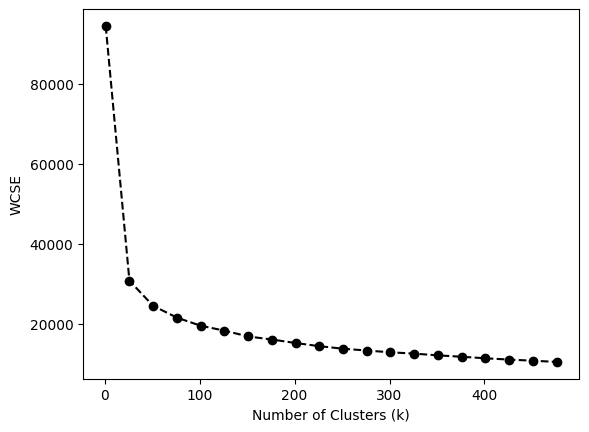

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

random_state = 42
# Elbow Plot Method
k_rng = range(1, 501, 25)
sse = []

# Compute WCSE for all possible total clusters.
for k in k_rng:
  km = KMeans(n_clusters=k, random_state=random_state)
  km.fit(X_reduced_train)
  sse.append(km.inertia_)
  print(f'K value {k} + inertia {km.inertia_}')

# Plot the Elbow Plot
plt.plot(k_rng, sse, linestyle='--', marker='o', color='black')
plt.xlabel("Number of Clusters (k)")
plt.ylabel('WCSE')

plt.plot




From the visual, we notice a significantly sharp decline when the number of clusters k = 26. We use 26 clusters from here on out moving forward.

In [16]:
# Set up the chosen K Means
hidden_size = 26
km = KMeans(n_clusters=hidden_size, random_state=random_state)
km.fit(X_reduced_train, y_reduced_train)

# Take the clustering centers
A = km.cluster_centers_

# Get the pseudo archetype information
print(f"Pseudo Archetype (A) : {A.shape}")
print(f'Weighted Cluster Sum of Square Errors - {km.inertia_}')


Pseudo Archetype (A) : (26, 140)
Weighted Cluster Sum of Square Errors - 30696.724317554184


#### Sample Random Probability Vectors Test Code

In [17]:
# Kraemer Algorithm for sampling random probability vectors on the simplex.
# Sum for i=1 to n, p_i >= 0
# Sum of the total probabilities must be equal to 1.

def sample_simplex_uniform(n_samples, n_dim, random_state = None):
  '''
  Sample random probability vectors on the simplex using the Kraemer Algorithm.

  Algorithm Steps:
  1. Select x_1,.....,x_(n-1) from a uniform distribution between 0 to 1.
  2. Sort the x_i in place.
  3. Compute the differences between the consecutive values.

  Args:
      n_samples: Number of probability vectors to generate
      n_dim: Dimension of each probability vector (hidden_size)
      random_state: Random seed for reproducibility

  Returns:
      codes: (n_samples, n_dim) array where each row sums to 1
  '''

  if random_state is not None:
    np.random.seed(random_state)

  # Step 1: Select the n-1 x values uniformly distribution between 0 to 1.
  samples_uniform = np.random.uniform(0, 1, size=(n_samples, n_dim - 1))

  # Achieve boundaries, sort them
  with_boundaries = np.concatenate(
      [np.zeros((n_samples, 1)),
       samples_uniform,
       np.ones((n_samples, 1))]
  , axis=1)

  # Step 2: Sort the x_is in place
  print(with_boundaries)
  sorted_values = np.sort(with_boundaries, axis=1)

  # Step 3: Take the differences between consecutive sorted values
  codes = np.diff(sorted_values, axis=1)
  assert np.allclose(codes.sum(axis=1), 1.0)

  return codes

In [18]:
# Generate the random codes for the training points.
n_train = X_reduced_train.shape[0]
random_codes = sample_simplex_uniform(
    n_samples=n_train,
    n_dim=hidden_size,
    random_state=45
)

# Print statements to test the sample simplex uniform functionality.
print(f'Random codes shape: {random_codes.shape}')
print(f'Codes sum to 1: {np.allclose(random_codes.sum(axis=1), 1.0)}')
print(f'All non-negative: {(random_codes >= 0).all()}')
print(f'Example code (first point): {random_codes[0, :5]}... (showing first 5)')
print(f'Example code sum: {random_codes[0].sum():.6f}')
print(f'Mean sparsity: {(random_codes > 0.01).sum(axis=1).mean():.2f} active components')

[[0.         0.98901151 0.54954473 ... 0.4785523  0.24275816 1.        ]
 [0.         0.38798252 0.81887343 ... 0.85586907 0.06693827 1.        ]
 [0.         0.18395199 0.17216682 ... 0.16127882 0.3049133  1.        ]
 ...
 [0.         0.07255303 0.89643799 ... 0.07871683 0.30290914 1.        ]
 [0.         0.66061246 0.0814084  ... 0.42618775 0.56064635 1.        ]
 [0.         0.00724539 0.27296102 ... 0.71440271 0.24688844 1.        ]]
Random codes shape: (10000, 26)
Codes sum to 1: True
All non-negative: True
Example code (first point): [0.048522   0.02876757 0.03517133 0.00348982 0.04737374]... (showing first 5)
Example code sum: 1.000000
Mean sparsity: 20.20 active components


#### Compute the Reconstruction to Locality Loss Ratio

In [19]:
def compute_loss_ratio(X, A, codes, batch_size=1000):
    """
    Compute the ratio of reconstruction loss to locality loss (memory-efficient).

    Args:
        X: (n_samples, input_size) data matrix
        A: (hidden_size, input_size) pseudo-dictionary (archetypes)
        codes: (n_samples, hidden_size) random probability vectors
        batch_size: Process this many samples at a time

    Returns:
        ratio: reconstruction_loss / locality_loss
        recon_loss: reconstruction loss value
        locality_loss: locality loss value
    """
    n_samples = X.shape[0]

    total_recon_loss = 0.0
    total_locality_loss = 0.0

    # Process in batches to save memory
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)

        X_batch = X[start_idx:end_idx]
        codes_batch = codes[start_idx:end_idx]
        batch_n = X_batch.shape[0]

        # Reconstruction: y_hat = codes @ A
        Y_hat_batch = codes_batch @ A

        # Reconstruction loss for this batch
        recon_batch = 0.5 * np.sum((X_batch - Y_hat_batch) ** 2)
        total_recon_loss += recon_batch

        # Locality loss: sum_j x_ij * ||y_i - a_j||^2
        # Compute using efficient matrix operations
        # distances_sq[i,j] = ||X_batch[i] - A[j]||^2

        # Method: ||a - b||^2 = ||a||^2 + ||b||^2 - 2*a·b
        X_sq = np.sum(X_batch ** 2, axis=1, keepdims=True)  # (batch_n, 1)
        A_sq = np.sum(A ** 2, axis=1, keepdims=True).T      # (1, hidden_size)
        XA = X_batch @ A.T                                    # (batch_n, hidden_size)

        distances_sq = X_sq + A_sq - 2 * XA  # (batch_n, hidden_size)

        # Locality loss for this batch
        locality_batch = np.sum(codes_batch * distances_sq)
        total_locality_loss += locality_batch

        # Optional: Print progress for large datasets
        if (end_idx % 50000) == 0:
            print(f'  Processed {end_idx}/{n_samples} samples...')

    # Average over all samples
    reconstruction_loss = total_recon_loss / n_samples
    locality_loss = total_locality_loss / n_samples

    # Compute ratio
    ratio = reconstruction_loss / locality_loss if locality_loss > 0 else np.inf

    return ratio, reconstruction_loss, locality_loss


# Step 3: Compute loss ratios (memory-efficient)
print("\nStep 3: Computing loss ratios with random codes...")

# You can now use the full training set
ratio, recon, locality = compute_loss_ratio(
    X_reduced_train,
    A,
    random_codes,
    batch_size=2000  # Adjust based on your memory
)

print(f'\nResults on {X_train.shape[0]} samples:')
print(f'Reconstruction loss: {recon:.6f}')
print(f'Locality loss: {locality:.6f}')
print(f'Ratio (recon/locality): {ratio:.6f}')
print(f'\nThis means locality is naturally {1/ratio:.2f}x larger than reconstruction')
print(f'Suggested C value (to balance): {ratio:.6f}')


Step 3: Computing loss ratios with random codes...

Results on 253993 samples:
Reconstruction loss: 4.987148
Locality loss: 17.374788
Ratio (recon/locality): 0.287034

This means locality is naturally 3.48x larger than reconstruction
Suggested C value (to balance): 0.287034


#### Run the experiment with multiple trials

In [20]:
# Multiple trials
def estimate_C_multiple_trials(X_train, hidden_size, n_trials=10, sample_size=10000, batch_size=2000, random_state = None):
  """
    Estimate C by running multiple trials with different:
    - K-means initializations
    - Random code samples

    Args:
        X_train: Training data (scaled)
        hidden_size: Number of archetypes/clusters
        n_trials: Number of independent trials
        sample_size: Number of data points to use per trial (for speed)
        batch_size: Batch size for loss computation

    Returns:
        ratios: List of ratios from each trial
        mean_C: Average C estimate
        std_C: Standard deviation of C estimates
    """

  if random_state is not None:
    np.random.seed(random_state)

  ratios = []
  for trial in range(n_trials):
    print(f'\n --- Trial {trial + 1} / {n_trials} ---')

    # Sample random indices of my data
    indices = np.random.choice(X_train.shape[0], size=sample_size, replace=False)
    X_sample = X_train[indices]

    # Step 1: K-Means with different initializations
    km = KMeans(n_clusters=hidden_size, random_state=trial, n_init=10)
    km.fit(X_sample)
    A = km.cluster_centers_
    print(f"Pseudo Archetype (A) : {A.shape}")
    print(f'Weighted Cluster Sum of Square Errors for trial {trial} - {km.inertia_}')

    # Step 2: Random sparse codes for each trial
    random_codes = sample_simplex_uniform(
        n_samples=sample_size,
        n_dim=hidden_size,
        random_state=trial * 10
    )

    # Step 3: Compute the loss ratio
    # You can now use the full training set
    ratio, recon, locality = compute_loss_ratio(
        X_sample,
        A,
        random_codes,
        batch_size=2000  # Adjust based on your memory
    )

    print(f'\n')
    print(f'Computed Ratio: {ratio:.6f}')
    print(f'Computed Recon: {recon:.6f}')
    print(f'Computed Locality: {locality:.6f}')

    ratios.append(ratio)

  ratios = np.array(ratios)
  mean_C_value = np.mean(ratios)
  std_C_value = np.std(ratios)

  return ratios, mean_C_value, std_C_value


In [21]:
# Run the multiple trials
ratios, mean_C, std_C = estimate_C_multiple_trials(
    X_train=X_train,
    hidden_size=hidden_size,
    n_trials=15,
    sample_size=10000,
    batch_size=2000,
    random_state=5
)

print(f'{"="*10}')
print("FINAL C ESTIMATION RESULTS")
print(f'Ratios across trials: {ratios}')
print(f'Mean C: {mean_C:.6f} ± {std_C:.6f}')
print(f'{"="*10}')


 --- Trial 1 / 15 ---
Pseudo Archetype (A) : (26, 140)
Weighted Cluster Sum of Square Errors for trial 0 - 30571.0562621697
[[0.         0.5488135  0.71518937 ... 0.78052918 0.11827443 1.        ]
 [0.         0.63992102 0.14335329 ... 0.31542835 0.36371077 1.        ]
 [0.         0.57019677 0.43860151 ... 0.60484552 0.73926358 1.        ]
 ...
 [0.         0.83000016 0.38628631 ... 0.0576148  0.41580769 1.        ]
 [0.         0.02088684 0.98353405 ... 0.54012008 0.65128691 1.        ]
 [0.         0.02621679 0.13640722 ... 0.68693019 0.1843027  1.        ]]


Computed Ratio: 0.285698
Computed Recon: 5.113821
Computed Locality: 17.899373

 --- Trial 2 / 15 ---
Pseudo Archetype (A) : (26, 140)
Weighted Cluster Sum of Square Errors for trial 1 - 30819.91299055242
[[0.         0.77132064 0.02075195 ... 0.67413362 0.44183317 1.        ]
 [0.         0.43401399 0.61776698 ... 0.32551164 0.1650159  1.        ]
 [0.         0.39252924 0.09346037 ... 0.63649114 0.34634715 1.        ]
 ...


#### Training of the KDS Model.

In [22]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import random
import tensorflow as tf
import torch
import numpy as np
import torch.optim as optim

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42) # Set torch seed

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_reduced_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_reduced_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_reduced_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_reduced_test, dtype=torch.float32)
X_val_tensor = torch.tensor(X_reduced_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_reduced_val, dtype=torch.float32)

# Create Tensor Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create Data Loaders
batch_size = 32  # You can adjust the batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [23]:
# Define the base path again to ensure it's correct
import os
base_path = '/content/drive/My Drive/Tufts/Masters Thesis Research/Car_Models_Completed_Numeric_Categorical_26_hidden_layers_15_encoding_layers'

# Check if the directory exists
if os.path.exists(base_path):
    print(f"Directory '{base_path}' exists.")
    print("Contents of the directory:")
    for item in os.listdir(base_path):
        print(f"- {item}")
else:
    print(f"Directory '{base_path}' DOES NOT exist. Please ensure the path is correct and your Drive is mounted properly.")

Directory '/content/drive/My Drive/Tufts/Masters Thesis Research/Car_Models_Completed_Numeric_Categorical_26_hidden_layers_15_encoding_layers' exists.
Contents of the directory:
- kds_model_0.01x sparse.pth
- kds_model_0.001x sparse.pth
- kds_model_0.0001x sparse.pth
- kds_model_0.00001x sparse.pth
- kds_model_0.000005x sparse.pth
- kds_model_0.35x sparse.pth
- kds_model_0.25x sparse.pth
- kds_model_0.1x sparse.pth
- kds_model_0.05x sparse.pth
- kds_model_0.035x sparse.pth


In [30]:
from tqdm import tqdm as progress_bar

input_size_features = X_train.shape[1]
print(f"[Model Init] input_size_features (from X_train.shape[1]): {input_size_features}") # Diagnostic print

hidden_size = hidden_size  # You can adjust the number of archetypes
num_layers = 15 # You can adjust the number of encoding layers
t_parameters = {
    '0.035x sparse': (mean_C * 0.035) / mean_C,
}
# Get the K-means cluster centers for W initialization (from previous steps)
# Ensure A is a tensor and on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-run K-means to get A based on X_reduced_train (which now has 37 features)
km = KMeans(n_clusters=hidden_size, random_state=random_state) # Use random_state from earlier
km.fit(X_reduced_train) # Fit on X_reduced_train which now has 37 features
A = km.cluster_centers_

print(f"[Model Init] Shape of A (after re-running KMeans): {A.shape}") # Diagnostic print

# A now has shape (hidden_size, input_size_features) i.e. (51, 37)
initial_W = torch.tensor(A, dtype=torch.float32).to(device)

num_epochs = 100

for i in range(len(t_parameters)):
  cur_key = list(t_parameters.keys())[i]
  cur_t = list(t_parameters.values())[i]

  # Instantiate the model with the correct input_size (37) and no price_column_index
  net = KDS(
      num_layers=num_layers,
      input_size=input_size_features, # Use the input_size_features (37)
      hidden_size=hidden_size,
      penalty=mean_C * cur_t, # Use the dynamic penalty from t_parameters
      accelerate=True,
      train_step=True,
      W=initial_W # Pass the K-means cluster centers as initial W,
  ).to(device)

  # Diagnostic prints to check the model object
  print(f"Type of 'model' before training loop: {type(net)}")
  print(f"Is 'model' an instance of KDS? {isinstance(net, KDS)}")
  print(f"Is 'model' an instance of torch.nn.Module? {isinstance(net, torch.nn.Module)}")
  print(f"[Model Init] Model's W shape: {net.W.shape}") # Diagnostic print

  # Define loss function and optimizer
  criterion = LocalDictionaryLoss(penalty=mean_C * cur_t)
  learning_rate = 1e-3
  num_epochs = 100 # This can be tuned
  optimizer = optim.Adam(net.parameters(), lr=0.001) # You can adjust the learning rate. Try 1e-4.

  train_losses = []
  val_losses = []

  print(f"Starting training for {num_epochs} epochs...")
  print(f'----- Cur Key Step: {cur_key}, Cur T Value: {cur_t} ------')

  with torch.no_grad():
      p = torch.randperm(len(train_dataset))[: net.hidden_size]
      net.W.data = X_train_tensor[p]
      net.step.fill_((net.W.data.svd()[1][0] ** -2).item())
  net = net.to(device)

  for epoch in progress_bar(range(num_epochs)):
      shuffle = torch.randperm(len(train_dataset))
      data, labels = X_train_tensor[shuffle], y_train_tensor[shuffle]
      for i in progress_bar(range(0, len(data), 32), disable=True):
          y = data[i : i + 32].to(device)
          x_hat = net.encode(y)
          loss = criterion(net.W, y, x_hat)
          optimizer.zero_grad()
          loss.backward()
          nn.utils.clip_grad_norm_(net.parameters(), 1e-4)
          optimizer.step()

      if epoch + 1 % 10 == 0:
          print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

  print("\n\nTraining finished.")

  file_name = f'kds_model_{cur_key}.pth'
  path = os.path.join(base_path, file_name)
  torch.save(net.state_dict(), path)

  # Create the directory if it does not exist
  os.makedirs(base_path, exist_ok=True)


[Model Init] input_size_features (from X_train.shape[1]): 140
[Model Init] Shape of A (after re-running KMeans): (26, 140)
Type of 'model' before training loop: <class '__main__.KDS'>
Is 'model' an instance of KDS? True
Is 'model' an instance of torch.nn.Module? True
[Model Init] Model's W shape: torch.Size([26, 140])
Starting training for 100 epochs...
----- Cur Key Step: 0.035x sparse, Cur T Value: 0.035 ------


100%|██████████| 100/100 [06:28<00:00,  3.88s/it]




Training finished.
Type of 'model' before training loop: <class '__main__.KDS'>
Is 'model' an instance of KDS? True
Is 'model' an instance of torch.nn.Module? True
[Model Init] Model's W shape: torch.Size([26, 140])
Starting training for 100 epochs...
----- Cur Key Step: 0.025x sparse, Cur T Value: 0.025 ------


  3%|▎         | 3/100 [00:12<06:54,  4.27s/it]


KeyboardInterrupt: 

### Model Evaluation and Synthesis


#### Load trained models from the disk

In [24]:
input_size_features = X_train.shape[1] # This should now be 37
print(f"[Model Init] input_size_features (from X_train.shape[1]): {input_size_features}") # Diagnostic print

hidden_size = hidden_size  # You can adjust the number of archetypes
num_layers = 15 # You can adjust the number of encoding layers
t_parameters = {
    '0.035x sparse': (mean_C * 0.035) / mean_C,
}

[Model Init] input_size_features (from X_train.shape[1]): 140


In [25]:
kds_model_names = ['0.035x sparse']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

kds_models = []
for i in range(len(kds_model_names)):
  cur_key = kds_model_names[i]
  cur_t = t_parameters[cur_key]

  # Re-run K-means to get A based on X_reduced_train (which now has 37 features)
  km = KMeans(n_clusters=hidden_size, random_state=random_state) # Use random_state from earlier
  km.fit(X_reduced_train) # Fit on X_reduced_train which now has 37 features
  A = km.cluster_centers_

  print(f"[Model Init] Shape of A (after re-running KMeans): {A.shape}") # Diagnostic print

  # A now has shape (hidden_size, input_size_features) i.e. (51, 37)
  initial_W = torch.tensor(A, dtype=torch.float32).to(device)

  net = KDS(
    num_layers=num_layers,
    input_size=input_size_features, # Use the input_size_features (37)
    hidden_size=hidden_size,
    penalty=mean_C * cur_t, # Use the dynamic penalty from t_parameters
    accelerate=True,
    train_step=True,
    W=initial_W # Pass the K-means cluster centers as initial W,
  ).to(device)

  full_pth = f'{base_path}/kds_model_{kds_model_names[i]}.pth'
  print(full_pth)
  net.load_state_dict(torch.load(full_pth))

  # Move the model to the device (e.g., GPU if available) if it was trained on it
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  net = net.to(device)

  kds_models.append(net)


[Model Init] Shape of A (after re-running KMeans): (26, 140)
/content/drive/My Drive/Tufts/Masters Thesis Research/Car_Models_Completed_Numeric_Categorical_26_hidden_layers_15_encoding_layers/kds_model_0.035x sparse.pth


In [26]:
# Get the sparse codes for all the models with the data points and the atoms.
model_sparse_codes = {}
individual_sparse_codes = []
for i in range(len(kds_model_names)):
  print(f"Model Name: {kds_model_names[i]}")
  model = kds_models[i]
  with torch.no_grad():
    y = torch.tensor(X_reduced_train, dtype=torch.float32).to(device)
    sparse_codes = model.encode(y)
    sparse_codes = sparse_codes.cpu().numpy()
    individual_sparse_codes.append(sparse_codes)
    model_sparse_codes[kds_model_names[i]] = sparse_codes

print(model_sparse_codes.keys())

Model Name: 0.035x sparse
dict_keys(['0.035x sparse'])


In [27]:
def analyze_sparsity(sparse_codes, tolerance=1e-5):
    """
    Analyze the sparsity pattern of KDS sparse codes

    Args:
        sparse_codes: (n_samples, hidden_size) array of sparse codes
        tolerance: Threshold below which values are considered zero

    Returns:
        Dictionary with sparsity statistics
    """
    print("="*70)
    print("TASK 1: SPARSITY ANALYSIS")
    print("="*70)

    # Apply tolerance threshold
    sparse_codes_binary = sparse_codes > tolerance

    # Count active components per sample
    active_per_sample = np.sum(sparse_codes_binary, axis=1)

    # Count how often each component is active
    active_per_component = np.sum(sparse_codes_binary, axis=0)

    # Statistics
    n_samples, hidden_size = sparse_codes.shape

    print(f"\nDataset: {n_samples} samples, {hidden_size} sparse dimensions")
    print(f"Tolerance: {tolerance}")

    print(f"\nSparsity per Sample:")
    print(f"  Mean active components: {active_per_sample.mean():.2f} / {hidden_size}")
    print(f"  Median active: {np.median(active_per_sample):.0f}")
    print(f"  Min active: {active_per_sample.min()}")
    print(f"  Max active: {active_per_sample.max()}")
    print(f"  Std: {active_per_sample.std():.2f}")
    print(f"  Sparsity: {(1 - active_per_sample.mean()/hidden_size)*100:.1f}%")

    print(f"\nComponent Usage:")
    print(f"  Components never used: {np.sum(active_per_component == 0)}")
    print(f"  Components always used: {np.sum(active_per_component == n_samples)}")
    print(f"  Mean usage: {active_per_component.mean():.1f} samples ({active_per_component.mean()/n_samples*100:.1f}%)")

    # Histogram of sparsity
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.hist(active_per_sample, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(active_per_sample.mean(), color='red', linestyle='--', label='Mean')
    plt.xlabel('Number of Active Components')
    plt.ylabel('Frequency')
    plt.title('Sparsity Distribution per Sample')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.hist(active_per_component, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(active_per_component.mean(), color='red', linestyle='--', label='Mean')
    plt.xlabel('Number of Samples Using Component')
    plt.ylabel('Frequency')
    plt.title('Component Usage Distribution')
    plt.legend()

    plt.subplot(1, 3, 3)
    # Show top 10 most active components
    top_components = np.argsort(active_per_component)[-10:]
    plt.barh(range(10), active_per_component[top_components])
    plt.yticks(range(10), [f'Comp {i}' for i in top_components])
    plt.xlabel('Usage Count')
    plt.title('Top 10 Most Used Components')

    plt.tight_layout()
    plt.savefig('sparsity_analysis.png', dpi=150, bbox_inches='tight')
    print("\n✓ Visualization saved as 'sparsity_analysis.png'")
    plt.show()

    return {
        'active_per_sample': active_per_sample,
        'active_per_component': active_per_component,
        'mean_sparsity': active_per_sample.mean(),
        'sparsity_percentage': (1 - active_per_sample.mean()/hidden_size)*100,
    }


#### Task 1: Sparsity Analysis

Purpose:

Understand how sparse the learned representations are and which components are most active.

Model Name: 0.035x sparse
TASK 1: SPARSITY ANALYSIS

Dataset: 10000 samples, 26 sparse dimensions
Tolerance: 0.0001

Sparsity per Sample:
  Mean active components: 6.06 / 26
  Median active: 6
  Min active: 3
  Max active: 22
  Std: 1.58
  Sparsity: 76.7%

Component Usage:
  Components never used: 0
  Components always used: 0
  Mean usage: 2331.5 samples (23.3%)

✓ Visualization saved as 'sparsity_analysis.png'


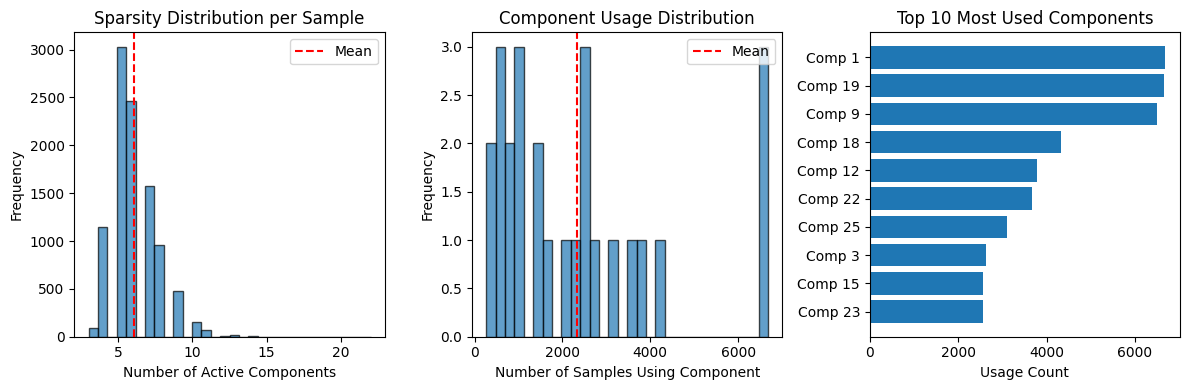

TASK 1: SPARSITY ANALYSIS

Dataset: 10000 samples, 26 sparse dimensions
Tolerance: 1e-05

Sparsity per Sample:
  Mean active components: 6.09 / 26
  Median active: 6
  Min active: 3
  Max active: 22
  Std: 1.59
  Sparsity: 76.6%

Component Usage:
  Components never used: 0
  Components always used: 0
  Mean usage: 2340.7 samples (23.4%)

✓ Visualization saved as 'sparsity_analysis.png'


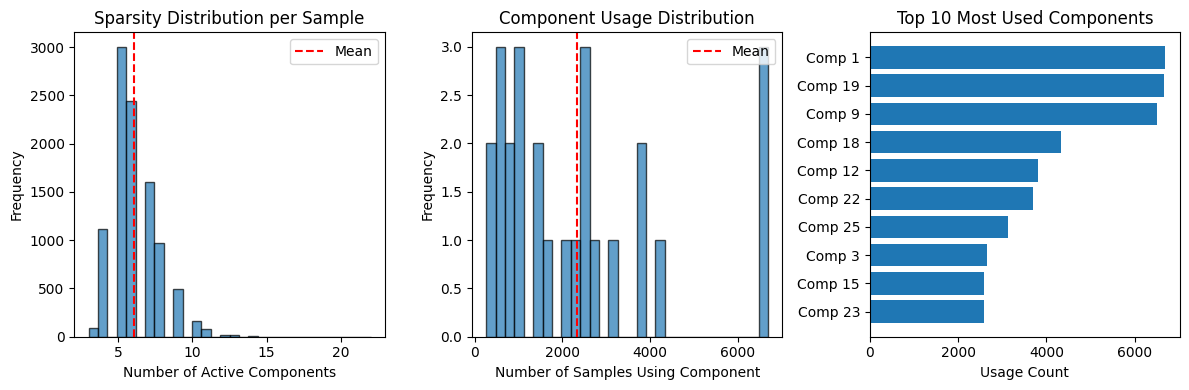

TASK 1: SPARSITY ANALYSIS

Dataset: 10000 samples, 26 sparse dimensions
Tolerance: 1e-06

Sparsity per Sample:
  Mean active components: 6.09 / 26
  Median active: 6
  Min active: 3
  Max active: 22
  Std: 1.59
  Sparsity: 76.6%

Component Usage:
  Components never used: 0
  Components always used: 0
  Mean usage: 2341.6 samples (23.4%)

✓ Visualization saved as 'sparsity_analysis.png'


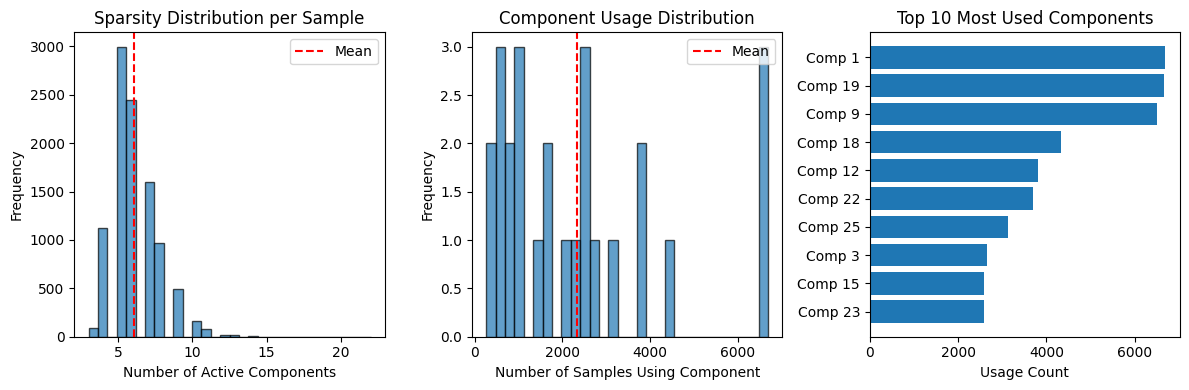

In [31]:
# After training KDS model and extracting sparse codes
for model in kds_model_names:
  print(f"Model Name: {model}")
  sparse_codes = model_sparse_codes[model]
  # Analyze sparsity with different tolerances
  for tolerance in [1e-4, 1e-5, 1e-6]:
      sparsity_stats = analyze_sparsity(sparse_codes, tolerance=tolerance)

#### Take the sparse features into a Ridge Regression model.

In [32]:
def adjusted_r_squared(r_squared, n, p):
  second_term = (1 - r_squared) * (n - 1) / (n-p-1)
  final_result = 1 - second_term
  return final_result

In [33]:
import numpy as np
from sklearn.linear_model import LinearRegression

epsilon = 1e-6

for model_name in kds_model_names:
  i = kds_model_names.index(model_name)
  net = kds_models[i]
  with torch.no_grad():
    # Extract sparse codes from your trained KDS model
    net.eval()
    sparse_codes_train = net.encode(torch.FloatTensor(X_reduced_train)).detach().numpy()
    sparse_codes_test = net.encode(torch.FloatTensor(X_reduced_test)).detach().numpy()

    # Train linear regression on sparse codes
    lr = LinearRegression()
    lr.fit(sparse_codes_train, y_reduced_train)
    y_pred = lr.predict(sparse_codes_test)

    # Evaluate (log space)
    rmse_log = np.sqrt(mean_squared_error(y_reduced_test, y_pred))
    r2 = r2_score(y_reduced_test, y_pred)
    adjusted_r2 = adjusted_r_squared(r2, len(y_reduced_test), sparse_codes_test.shape[1])

    # Evaluate (dollar space)
    y_test_dollars = np.expm1(y_reduced_test) + epsilon # Division by zero errors.
    y_pred_dollars = np.expm1(y_pred)
    mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)

    y_pred_dollars = price_scaler.inverse_transform(y_pred).ravel()
    rmse = np.sqrt(mean_squared_error(y_reduced_test, y_pred_dollars))
    mape = np.mean(np.abs((y_test_dollars - y_pred_dollars) / y_test_dollars)) * 100 # Mean Absolute Percentage error.

    # Predictive Groups to gauge price representations
    within_5k = np.sum(np.abs(y_test_dollars - y_pred_dollars) < 5000) / len(y_pred) * 100
    within_10k = np.sum(np.abs(y_test_dollars - y_pred_dollars) < 10000) / len(y_pred) * 100
    within_15k = np.sum(np.abs(y_test_dollars - y_pred_dollars) < 15000) / len(y_pred) * 100

    print("="*60)
    print(f"LINEAR REGRESSION ON KDS SPARSE CODES for KDS model {model_name}")
    print("="*60)
    print(f"\n Model Coefficients: ")
    print(f"Current model coefficients for {model_name} - {lr.coef_}")
    print(f"RMSE (log): {rmse_log:.4f} | RMSE: ${rmse:.4f} | R²: {r2:.4f} | Adjusted R²: {adjusted_r2:4f}")
    print(f"MAE: ${mae_dollars:,.0f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"\nPredictive Performance:")
    print(f"  Within ±$5,000:  {within_5k:.1f}%")
    print(f"  Within ±$10,000: {within_10k:.1f}%")
    print(f"  Within ±$15,000: {within_10k:.1f}%")
    print("="*60)


LINEAR REGRESSION ON KDS SPARSE CODES for KDS model 0.035x sparse

 Model Coefficients: 
Current model coefficients for 0.035x sparse - [[-0.36087796 -0.59344876 -0.00112858 -0.26896176  0.4208824   0.5665557
   0.13940476 -0.9169576  -0.02743446  0.7152921   0.03049687 -0.13478932
   0.17385913 -0.12146762  0.18275382 -0.05943135 -0.13800909  0.23857556
   0.1769278  -0.08147852 -0.05752782 -0.35782662  0.09473605  0.49173024
   0.08232071 -0.19419612]]
RMSE (log): 0.2326 | RMSE: $18361.3462 | R²: 0.3707 | Adjusted R²: 0.367360
MAE: $0
MAPE: 110366769249.13%

Predictive Performance:
  Within ±$5,000:  25700.0%
  Within ±$10,000: 190000.0%
  Within ±$15,000: 190000.0%


#### Sparse Codes Training.

In [34]:
# Test Gradient Boosting vs Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score
import numpy as np

print("Testing Gradient Boosting...")

for model_name in kds_model_names:
  i = kds_model_names.index(model_name)
  net = kds_models[i]
  with torch.no_grad():
    # Extract sparse codes from your trained KDS model
    net.eval()
    sparse_codes_train = net.encode(torch.FloatTensor(X_train)).detach().numpy()
    sparse_codes_test = net.encode(torch.FloatTensor(X_test)).detach().numpy()

    # Use Histogram Gradient Boosting (fast on large datasets)
    gb = HistGradientBoostingRegressor(
        max_iter=300,
        max_depth=10,
        learning_rate=0.05,
        random_state=42,
        verbose=1
    )

    # Train on full sparse codes
    gb.fit(sparse_codes_train, y_train.ravel())

    # Predict
    y_test_gb = gb.predict(sparse_codes_test)
    r2_gb = r2_score(y_test.ravel(), y_test_gb)
    adjusted_r2_gb = adjusted_r_squared(r2, len(y_test), sparse_codes_test.shape[1])

    # Convert to dollars
    y_pred_dollars = price_scaler.inverse_transform(y_test_gb.reshape(-1, 1)).ravel()
    rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_dollars))

    print(f"\n{'='*70}")
    print(f"RESULTS:")
    print(f"  Ridge R²: 0.43-0.45")
    print(f"  GB R²:    {r2_gb:.4f}")
    print(f"  Adjusted GB R²:    {adjusted_r2_gb:.4f}")
    print(f"  Improvement: {r2_gb - 0.45:+.4f}")
    print(f"  Adjusted R² Improvement: {adjusted_r2_gb - 0.45:+.4f}")
    print(f"  RMSE: ${rmse_gb:,.2f}")
    print(f"{'='*70}")

    if r2_gb >= 0.50:
        print("\n✓✓ SUCCESS! Ready for clustering!")
    else:
        print("\n→ Need further optimization")

Testing Gradient Boosting...
Binning 0.048 GB of training data: 0.950 s
Binning 0.005 GB of validation data: 0.034 s
Fitting gradient boosted rounds:
Fit 300 trees in 15.208 s, (9300 total leaves)
Time spent computing histograms: 10.136s
Time spent finding best splits:  0.790s
Time spent applying splits:      1.520s
Time spent predicting:           0.210s

RESULTS:
  Ridge R²: 0.43-0.45
  GB R²:    0.4883
  Adjusted GB R²:    0.3705
  Improvement: +0.0383
  Adjusted R² Improvement: -0.0795
  RMSE: $17,187.77

→ Need further optimization


#### Clustering the Car Data Appropriately

In [43]:
def apply_sparsity_threshold(sparse_codes, tolerance=1e-5):
    """
    Apply tolerance threshold as recommended by Abiy
    """
    sparse_codes_thresh = sparse_codes.copy()
    sparse_codes_thresh[sparse_codes_thresh < tolerance] = 0

    print(f"\nApplying sparsity threshold: {tolerance}")
    print(f"  Original range: [{sparse_codes.min():.6f}, {sparse_codes.max():.6f}]")
    print(f"  After threshold: [{sparse_codes_thresh.min():.6f}, {sparse_codes_thresh.max():.6f}]")
    print(f"  Zeros: {np.sum(sparse_codes_thresh == 0):,} / {sparse_codes_thresh.size:,} "
          f"({np.sum(sparse_codes_thresh == 0)/sparse_codes_thresh.size*100:.1f}%)")

    return sparse_codes_thresh


In [44]:
def visualize_clusters(sparse_codes, labels, df_subset, n_clusters):
    """
    Create comprehensive visualizations
    """
    print("\n" + "="*70)
    print("CLUSTER VISUALIZATIONS")
    print("="*70)

    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    import seaborn as sns

    # PCA for 2D visualization
    print("\nReducing to 2D with PCA...")
    pca = PCA(n_components=2, random_state=42)
    coords_2d = pca.fit_transform(sparse_codes)

    explained_var = pca.explained_variance_ratio_.sum() * 100
    print(f"  Explained variance: {explained_var:.1f}%")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Cluster scatter plot
    scatter = axes[0, 0].scatter(coords_2d[:, 0], coords_2d[:, 1],
                                 c=labels, cmap='tab10', alpha=0.6, s=10)
    axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0, 0].set_title('Clusters in 2D (PCA)')
    plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

    # 2. Price distribution by cluster
    if 'price' in df_subset.columns:
        df_plot = df_subset.copy()
        df_plot['cluster'] = labels

        for cluster_id in range(n_clusters):
            cluster_prices = df_plot[df_plot['cluster'] == cluster_id]['price']
            axes[0, 1].hist(cluster_prices, bins=30, alpha=0.5,
                           label=f'Cluster {cluster_id}', density=True)

        axes[0, 1].set_xlabel('Price ($)')
        axes[0, 1].set_ylabel('Density')
        axes[0, 1].set_title('Price Distribution by Cluster')
        axes[0, 1].legend()
        axes[0, 1].set_xscale('log')

    # 3. Cluster sizes
    cluster_sizes = [np.sum(labels == i) for i in range(n_clusters)]
    axes[0, 2].bar(range(n_clusters), cluster_sizes)
    axes[0, 2].set_xlabel('Cluster')
    axes[0, 2].set_ylabel('Number of Cars')
    axes[0, 2].set_title('Cluster Sizes')
    axes[0, 2].set_xticks(range(n_clusters))

    # 4. Age distribution by cluster
    if 'age' in df_subset.columns:
        df_plot['age'] = df_subset['age'].values

        boxplot_data = [df_plot[df_plot['cluster'] == i]['age'].values
                       for i in range(n_clusters)]
        axes[1, 0].boxplot(boxplot_data, labels=[f'C{i}' for i in range(n_clusters)])
        axes[1, 0].set_xlabel('Cluster')
        axes[1, 0].set_ylabel('Age (years)')
        axes[1, 0].set_title('Age Distribution by Cluster')

    # 5. Mileage distribution by cluster
    if 'odometer' in df_subset.columns:
        df_plot['odometer'] = df_subset['odometer'].values

        boxplot_data = [df_plot[df_plot['cluster'] == i]['odometer'].values
                       for i in range(n_clusters)]
        axes[1, 1].boxplot(boxplot_data, labels=[f'C{i}' for i in range(n_clusters)])
        axes[1, 1].set_xlabel('Cluster')
        axes[1, 1].set_ylabel('Mileage (miles)')
        axes[1, 1].set_title('Mileage Distribution by Cluster')
        axes[1, 1].set_yscale('log')

    # 6. Price vs Mileage by cluster
    if 'price' in df_subset.columns and 'odometer' in df_subset.columns:
        for cluster_id in range(n_clusters):
            cluster_mask = labels == cluster_id
            axes[1, 2].scatter(df_subset[cluster_mask]['odometer'],
                             df_subset[cluster_mask]['price'],
                             alpha=0.3, s=10, label=f'Cluster {cluster_id}')

        axes[1, 2].set_xlabel('Mileage (miles)')
        axes[1, 2].set_ylabel('Price ($)')
        axes[1, 2].set_title('Price vs Mileage by Cluster')
        axes[1, 2].legend()
        axes[1, 2].set_xscale('log')
        axes[1, 2].set_yscale('log')

    plt.tight_layout()
    plt.savefig('cluster_visualizations.png', dpi=150, bbox_inches='tight')
    print("\n✓ Visualizations saved as 'cluster_visualizations.png'")
    plt.show()



In [52]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ============================================================================
# STRATEGY: PLS on Sparse Codes + Feature Reconstruction Analysis
# ============================================================================
# This approach:
# 1. Runs PLS on KDS sparse codes to find price-predictive patterns
# 2. Clusters on PLS components
# 3. Maps back to original features to show what each cluster represents
# 4. Analyzes feature importance per cluster
# ============================================================================

def integrated_pls_clustering(sparse_codes, X_original, y_price, df_metadata,
                              kds_model, feature_names,
                              n_pls_components=10, n_clusters=5,
                              batch_size=1000, price_scaler=price_scaler):
    """
    Complete integrated analysis: Sparse codes → PLS → Clusters → Feature analysis

    Args:
        sparse_codes: KDS learned representations (n_samples, hidden_size)
        X_original: Original feature matrix (n_samples, n_features)
        y_price: Price target - MUST BE ORIGINAL SCALE (n_samples,)
        df_metadata: DataFrame with manufacturer, type, etc.
        kds_model: Trained KDS model (for reconstruction)
        feature_names: List of original feature names
        n_pls_components: Number of PLS components
        n_clusters: Number of clusters
        batch_size: Batch size for clustering

    Returns:
        results: Dictionary with comprehensive analysis
    """
    print(f"\n{'#'*70}")
    print("INTEGRATED PLS CLUSTERING ANALYSIS")
    print(f"{'#'*70}")

    results = {}

    # ========================================================================
    # STEP 1: PLS on Sparse Codes (Find price-predictive sparse patterns)
    # ========================================================================
    print(f"\n{'='*70}")
    print("STEP 1: PLS ON SPARSE CODES")
    print(f"{'='*70}")
    print(f"Sparse codes shape: {sparse_codes.shape}")
    print(f"Price target shape: {y_price.shape}")
    print(f"Price range: ${y_price.min():,.2f} - ${y_price.max():,.2f}")

    # Flatten y if needed
    y_price = price_scaler.inverse_transform(y_price.reshape(-1, 1)).ravel()
    y_flat = y_price.ravel() if len(y_price.shape) > 1 else y_price

    # Fit PLS on sparse codes
    pls_sparse = PLSRegression(n_components=n_pls_components, scale=True)
    sparse_codes_pls = pls_sparse.fit_transform(sparse_codes, y_flat)[0]

    # Evaluate PLS quality
    y_pred_pls = pls_sparse.predict(sparse_codes).ravel()
    r2_pls = r2_score(y_flat, y_pred_pls)
    mae_pls = mean_absolute_error(y_flat, y_pred_pls)

    print(f"\nPLS Performance on Sparse Codes:")
    print(f"  R²:  {r2_pls:.4f}")
    print(f"  MAE: ${mae_pls:,.2f}")
    print(f"  PLS components shape: {sparse_codes_pls.shape}")

    results['pls_model'] = pls_sparse
    results['pls_components'] = sparse_codes_pls
    results['pls_predictions'] = y_pred_pls
    results['pls_r2'] = r2_pls

    # ========================================================================
    # STEP 2: Cluster on PLS Components
    # ========================================================================
    print(f"\n{'='*70}")
    print(f"STEP 2: CLUSTERING ON PLS COMPONENTS (k={n_clusters})")
    print(f"{'='*70}")

    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        batch_size=batch_size,
        random_state=42,
        n_init=20
    )
    cluster_labels = kmeans.fit_predict(sparse_codes_pls)

    print(f"Cluster sizes: {np.bincount(cluster_labels)}")

    results['cluster_labels'] = cluster_labels
    results['cluster_centers'] = kmeans.cluster_centers_

    # ========================================================================
    # STEP 3: Reconstruct Features from Sparse Codes per Cluster
    # ========================================================================
    print(f"\n{'='*70}")
    print("STEP 3: FEATURE RECONSTRUCTION ANALYSIS")
    print(f"{'='*70}")

    # Get reconstructed features from KDS
    # X_reconstructed = sparse_codes @ kds_model.W (if W is accessible)
    import torch
    with torch.no_grad():
        if hasattr(kds_model, 'W'):
            W_np = kds_model.W.cpu().numpy() if torch.is_tensor(kds_model.W) else kds_model.W
            X_reconstructed = sparse_codes @ W_np
            print(f"Reconstructed features shape: {X_reconstructed.shape}")
        else:
            print("Warning: KDS model W not accessible, using original features")
            X_reconstructed = X_original

    results['X_reconstructed'] = X_reconstructed

    # ========================================================================
    # STEP 4: Analyze Each Cluster - Features + Prediction Performance
    # ========================================================================
    print(f"\n{'='*70}")
    print("STEP 4: CLUSTER ANALYSIS WITH FEATURE IMPORTANCE")
    print(f"{'='*70}")

    cluster_analysis = analyze_clusters_with_features(
        df_metadata=df_metadata,
        cluster_labels=cluster_labels,
        X_reconstructed=X_reconstructed,
        X_original=X_original,
        feature_names=feature_names,
        y_true=y_flat,
        y_pred=y_pred_pls,
        top_n_features=10
    )

    results['cluster_analysis'] = cluster_analysis

    # ========================================================================
    # STEP 5: Feature Importance Across Clusters
    # ========================================================================
    print(f"\n{'='*70}")
    print("STEP 5: FEATURE IMPORTANCE ANALYSIS")
    print(f"{'='*70}")

    feature_importance = compute_feature_importance_by_cluster(
        X_reconstructed=X_reconstructed,
        cluster_labels=cluster_labels,
        feature_names=feature_names,
        n_clusters=n_clusters,
        top_n=15
    )

    results['feature_importance'] = feature_importance

    # ========================================================================
    # STEP 6: Visualizations
    # ========================================================================
    print(f"\n{'='*70}")
    print("STEP 6: GENERATING VISUALIZATIONS")
    print(f"{'='*70}")

    visualize_integrated_analysis(
        sparse_codes_pls=sparse_codes_pls,
        cluster_labels=cluster_labels,
        y_true=y_flat,
        y_pred=y_pred_pls,
        df_metadata=df_metadata,
        feature_importance=feature_importance,
        n_clusters=n_clusters
    )

    # ========================================================================
    # STEP 7: Create Comprehensive DataFrame
    # ========================================================================
    df_complete = create_integrated_dataframe(
        df_metadata=df_metadata,
        sparse_codes=sparse_codes,
        pls_components=sparse_codes_pls,
        cluster_labels=cluster_labels,
        y_true=y_flat,
        y_pred=y_pred_pls,
        X_reconstructed=X_reconstructed,
        feature_names=feature_names
    )

    results['df_complete'] = df_complete

    print(f"\n{'#'*70}")
    print("✓ INTEGRATED ANALYSIS COMPLETE")
    print(f"{'#'*70}")

    return results


def analyze_clusters_with_features(df_metadata, cluster_labels, X_reconstructed,
                                   X_original, feature_names, y_true, y_pred,
                                   top_n_features=10, price_scaler = price_scaler):
    """
    Analyze each cluster with feature importance
    """
    df = df_metadata.copy()
    df['cluster'] = cluster_labels
    df['price_true'] = y_true
    df['price_pred'] = y_pred
    df['abs_error'] = np.abs(y_true - y_pred)
    df['pct_error'] = np.where(y_true > 0, (df['abs_error'] / y_true) * 100, 0)

    n_clusters = len(np.unique(cluster_labels))
    summaries = []

    for c in range(n_clusters):
        cluster_mask = cluster_labels == c
        cluster_data = df[cluster_mask]
        n = len(cluster_data)

        print(f"\n{'━'*70}")
        print(f"CLUSTER {c}: {n:,} vehicles ({100*n/len(df):.1f}%)")
        print(f"{'━'*70}")

        summary = {'cluster': c, 'size': n, 'pct': 100*n/len(df)}

        # ===== PREDICTION PERFORMANCE =====
        mae = cluster_data['abs_error'].mean()
        mape = cluster_data['pct_error'].mean()
        rmse = np.sqrt((cluster_data['abs_error'] ** 2).mean())

        ss_res = ((cluster_data['price_true'] - cluster_data['price_pred']) ** 2).sum()
        ss_tot = ((cluster_data['price_true'] - cluster_data['price_true'].mean()) ** 2).sum()
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        print(f"\n📊 PREDICTION PERFORMANCE:")
        print(f"   R²:   {r2:.4f}")
        print(f"   MAE:  ${mae:,.0f}")
        print(f"   MAPE: {mape:.1f}%")

        summary.update({'r2': r2, 'mae': mae, 'mape': mape, 'rmse': rmse})

        # ===== PRICE DISTRIBUTION =====
        med_price = cluster_data['price_true'].median()
        mean_price = cluster_data['price_true'].mean()
        summary['median_price'] = med_price
        summary['mean_price'] = mean_price

        print(f"\n💰 PRICE:")
        print(f"   Median: ${med_price:,.0f}")
        print(f"   Mean:   ${mean_price:,.0f}")
        print(f"   Range:  ${cluster_data['price_true'].min():,.0f} - ${cluster_data['price_true'].max():,.0f}")

        # ===== TOP FEATURES (Reconstructed) =====
        X_cluster = X_reconstructed[cluster_mask]
        feature_means = X_cluster.mean(axis=0)
        feature_stds = X_cluster.std(axis=0)

        # Get overall means for comparison
        overall_means = X_reconstructed.mean(axis=0)

        # Compute deviation from overall mean (normalized by std)
        deviations = (feature_means - overall_means) / (feature_stds + 1e-8)
        top_feature_idx = np.argsort(np.abs(deviations))[-top_n_features:][::-1]

        print(f"\n🔍 TOP {top_n_features} DISTINCTIVE FEATURES:")
        print(f"   {'Feature':<35} {'Cluster Mean':<15} {'Overall Mean':<15} {'Deviation':<10}")
        print(f"   {'-'*75}")

        top_features_list = []
        for idx in top_feature_idx:
            feat_name = feature_names[idx] if idx < len(feature_names) else f"Feature_{idx}"
            cluster_mean = feature_means[idx]
            overall_mean = overall_means[idx]
            deviation = deviations[idx]

            print(f"   {feat_name:<35} {cluster_mean:<15.3f} {overall_mean:<15.3f} {deviation:<10.2f}")
            top_features_list.append({
                'feature': feat_name,
                'cluster_mean': cluster_mean,
                'overall_mean': overall_mean,
                'deviation': deviation
            })

        summary['top_features'] = top_features_list

        # ===== METADATA (Manufacturer, Type, etc.) =====
        if 'manufacturer' in df.columns:
            top_mfrs = cluster_data['manufacturer'].value_counts().head(3)
            print(f"\n🏭 TOP 3 MANUFACTURERS:")
            mfr_list = []
            for mfr, count in top_mfrs.items():
                pct = (count / n) * 100
                print(f"   {mfr:<20} {pct:>5.1f}%")
                mfr_list.append(f"{mfr} ({pct:.0f}%)")
            summary['top_manufacturers'] = " | ".join(mfr_list)

        if 'type' in df.columns:
            top_types = cluster_data['type'].value_counts().head(3)
            print(f"\n🚗 TOP 3 VEHICLE TYPES:")
            type_list = []
            for vtype, count in top_types.items():
                pct = (count / n) * 100
                print(f"   {vtype:<20} {pct:>5.1f}%")
                type_list.append(f"{vtype} ({pct:.0f}%)")
            summary['top_types'] = " | ".join(type_list)

        # ===== CLUSTER NAME =====
        cluster_name = generate_integrated_cluster_name(summary, cluster_data, r2)
        summary['cluster_name'] = cluster_name
        print(f"\n🏷  CLUSTER NAME: '{cluster_name}'")

        summaries.append(summary)
        gc.collect()

    return pd.DataFrame(summaries)


def generate_integrated_cluster_name(summary, cluster_data, r2):
    """Generate distinctive name based on prediction + features + metadata"""
    components = []

    # Prediction quality
    if r2 > 0.65:
        pred_label = "Well-Predictable"
    elif r2 > 0.45:
        pred_label = "Moderately-Predictable"
    elif r2 > 0.3:
        pred_label = "Challenging"
    else:
        pred_label = "Hard-to-Predict"

    components.append(pred_label)

    # Dominant manufacturer (if >25%)
    if 'manufacturer' in cluster_data.columns:
        top_mfr_counts = cluster_data['manufacturer'].value_counts()
        if len(top_mfr_counts) > 0:
            top_mfr = top_mfr_counts.index[0]
            top_mfr_pct = top_mfr_counts.values[0] / len(cluster_data) * 100
            if top_mfr_pct > 25:
                components.append(top_mfr.title())

    # Dominant type (if >30%)
    if 'type' in cluster_data.columns:
        top_type_counts = cluster_data['type'].value_counts()
        if len(top_type_counts) > 0:
            top_type = top_type_counts.index[0]
            top_type_pct = top_type_counts.values[0] / len(cluster_data) * 100
            if top_type_pct > 30:
                components.append(top_type.title() + "s")

    # Price tier
    if 'median_price' in summary:
        price = summary['median_price']
        if price < 8000:
            components.append("Budget")
        elif price < 15000:
            components.append("Value")
        elif price < 25000:
            components.append("Mid")
        elif price < 40000:
            components.append("Premium")
        else:
            components.append("Luxury")

    # Ensure uniqueness
    name = " ".join(components)
    if len(components) < 3:
        name += f" C{summary['cluster']}"

    return name


def compute_feature_importance_by_cluster(X_reconstructed, cluster_labels,
                                         feature_names, n_clusters, top_n=15):
    """
    Compute which features are most distinctive for each cluster
    """
    print("\nComputing feature importance by cluster...")

    feature_importance = {}
    overall_mean = X_reconstructed.mean(axis=0)
    overall_std = X_reconstructed.std(axis=0)

    for c in range(n_clusters):
        cluster_mask = cluster_labels == c
        X_cluster = X_reconstructed[cluster_mask]

        cluster_mean = X_cluster.mean(axis=0)

        # Normalized deviation from overall
        deviation = (cluster_mean - overall_mean) / (overall_std + 1e-8)

        # Get top features
        top_idx = np.argsort(np.abs(deviation))[-top_n:][::-1]

        feature_importance[c] = pd.DataFrame({
            'feature': [feature_names[i] if i < len(feature_names) else f"F{i}"
                       for i in top_idx],
            'cluster_mean': cluster_mean[top_idx],
            'overall_mean': overall_mean[top_idx],
            'deviation': deviation[top_idx],
            'abs_deviation': np.abs(deviation[top_idx])
        })

    return feature_importance


def create_integrated_dataframe(df_metadata, sparse_codes, pls_components,
                               cluster_labels, y_true, y_pred,
                               X_reconstructed, feature_names):
    """
    Create comprehensive DataFrame with all information
    """
    print("\nCreating integrated DataFrame...")

    df_complete = df_metadata.copy()

    # Add cluster info
    df_complete['cluster'] = cluster_labels
    df_complete['price_true'] = y_true
    df_complete['price_pred'] = y_pred
    df_complete['abs_error'] = np.abs(y_true - y_pred)
    df_complete['pct_error'] = np.where(y_true > 0,
                                        (df_complete['abs_error'] / y_true) * 100,
                                        0)

    # Add PLS components (first 5 for interpretability)
    n_pls_to_save = min(5, pls_components.shape[1])
    for i in range(n_pls_to_save):
        df_complete[f'pls_comp_{i+1}'] = pls_components[:, i]

    # Add sparse code summary (e.g., sparsity, top active components)
    df_complete['sparse_active_count'] = (sparse_codes > 1e-5).sum(axis=1)
    df_complete['sparse_max_activation'] = sparse_codes.max(axis=1)

    # Add reconstructed feature summary (optional - only if small number)
    if X_reconstructed.shape[1] <= 10:
        for i, fname in enumerate(feature_names[:X_reconstructed.shape[1]]):
            df_complete[f'recon_{fname}'] = X_reconstructed[:, i]

    print(f"Complete DataFrame shape: {df_complete.shape}")

    return df_complete


def visualize_integrated_analysis(sparse_codes_pls, cluster_labels, y_true, y_pred,
                                  df_metadata, feature_importance, n_clusters):
    """
    Comprehensive visualizations
    """
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

    # 1. Clusters in PLS space
    ax1 = fig.add_subplot(gs[0, 0])
    scatter = ax1.scatter(sparse_codes_pls[:, 0], sparse_codes_pls[:, 1],
                         c=cluster_labels, cmap='tab10', alpha=0.5, s=3)
    ax1.set_xlabel('PLS Component 1')
    ax1.set_ylabel('PLS Component 2')
    ax1.set_title('Clusters in PLS Space')
    plt.colorbar(scatter, ax=ax1)

    # 2. True vs Predicted by cluster
    ax2 = fig.add_subplot(gs[0, 1])
    for c in range(n_clusters):
        mask = cluster_labels == c
        ax2.scatter(y_true[mask], y_pred[mask], alpha=0.3, s=3, label=f'C{c}')
    ax2.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
             'k--', alpha=0.3)
    ax2.set_xlabel('True Price ($)')
    ax2.set_ylabel('Predicted Price ($)')
    ax2.set_title('Predictions by Cluster')
    ax2.legend(markerscale=2, fontsize=8)
    ax2.set_xscale('log')
    ax2.set_yscale('log')

    # 3. Prediction error by cluster
    ax3 = fig.add_subplot(gs[0, 2])
    errors = [np.abs(y_true[cluster_labels == c] - y_pred[cluster_labels == c])
              for c in range(n_clusters)]
    ax3.boxplot(errors, labels=[f'C{c}' for c in range(n_clusters)])
    ax3.set_ylabel('Absolute Error ($)')
    ax3.set_title('Error Distribution by Cluster')
    ax3.set_yscale('log')

    # 4. R² by cluster
    ax4 = fig.add_subplot(gs[0, 3])
    r2_scores = []
    for c in range(n_clusters):
        mask = cluster_labels == c
        if mask.sum() > 0:
            r2 = r2_score(y_true[mask], y_pred[mask])
            r2_scores.append(r2)
        else:
            r2_scores.append(0)
    ax4.bar(range(n_clusters), r2_scores, color='steelblue', alpha=0.7)
    ax4.set_xlabel('Cluster')
    ax4.set_ylabel('R² Score')
    ax4.set_title('Prediction Quality by Cluster')
    ax4.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    ax4.set_xticks(range(n_clusters))

    # 5. Price distribution by cluster
    ax5 = fig.add_subplot(gs[1, 0])
    price_by_cluster = [y_true[cluster_labels == c] for c in range(n_clusters)]
    ax5.boxplot(price_by_cluster, labels=[f'C{c}' for c in range(n_clusters)])
    ax5.set_ylabel('Price ($)')
    ax5.set_title('Price Distribution by Cluster')
    ax5.set_yscale('log')

    # 6. Cluster sizes
    ax6 = fig.add_subplot(gs[1, 1])
    sizes = [np.sum(cluster_labels == c) for c in range(n_clusters)]
    ax6.bar(range(n_clusters), sizes, color='coral', alpha=0.7)
    ax6.set_xlabel('Cluster')
    ax6.set_ylabel('Count')
    ax6.set_title('Cluster Sizes')
    ax6.set_xticks(range(n_clusters))

    # 7. Feature importance heatmap (top 10 features per cluster)
    ax7 = fig.add_subplot(gs[1, 2:])
    importance_matrix = []
    feature_labels = []

    for c in range(n_clusters):
        if c in feature_importance:
            top_5 = feature_importance[c].head(5)
            if c == 0:
                feature_labels = top_5['feature'].tolist()
            importance_matrix.append(top_5['abs_deviation'].values)

    if importance_matrix:
        importance_matrix = np.array(importance_matrix).T
        im = ax7.imshow(importance_matrix, aspect='auto', cmap='YlOrRd')
        ax7.set_xticks(range(n_clusters))
        ax7.set_xticklabels([f'C{c}' for c in range(n_clusters)])
        ax7.set_yticks(range(len(feature_labels)))
        ax7.set_yticklabels(feature_labels, fontsize=8)
        ax7.set_title('Top 5 Features by Cluster (Deviation from Overall)')
        plt.colorbar(im, ax=ax7)

    # 8-11. Manufacturer and type distributions
    if 'manufacturer' in df_metadata.columns:
        ax8 = fig.add_subplot(gs[2, 0:2])
        mfr_cluster = []
        for c in range(n_clusters):
            mask = cluster_labels == c
            top_mfrs = df_metadata[mask]['manufacturer'].value_counts().head(3)
            mfr_cluster.append(top_mfrs.to_dict())

        # Create stacked bar chart
        all_mfrs = set()
        for d in mfr_cluster:
            all_mfrs.update(d.keys())

        ax8.set_xlabel('Cluster')
        ax8.set_ylabel('Count')
        ax8.set_title('Top Manufacturers by Cluster')
        ax8.legend(fontsize=8)

    if 'type' in df_metadata.columns:
        ax9 = fig.add_subplot(gs[2, 2:])
        for c in range(n_clusters):
            mask = cluster_labels == c
            type_counts = df_metadata[mask]['type'].value_counts().head(5)
            ax9.barh([f"C{c}-{t}" for t in type_counts.index],
                    type_counts.values, alpha=0.7)
        ax9.set_xlabel('Count')
        ax9.set_title('Top Vehicle Types by Cluster')

    plt.savefig('integrated_pls_analysis.png', dpi=120, bbox_inches='tight')
    print("\n✓ Saved visualization as 'integrated_pls_analysis.png'")
    plt.show()

    gc.collect()


In [49]:
sparse_codes = model_sparse_codes['0.035x sparse']
df_subset = df_encoded.iloc[random_indices].reset_index(drop=True)
print(df_subset)

                                                    url  \
0     https://orlando.craigslist.org/ctd/d/kissimmee...   
1     https://modesto.craigslist.org/ctd/d/fair-oaks...   
2     https://chicago.craigslist.org/chc/ctd/d/wauke...   
3     https://ocala.craigslist.org/ctd/d/tampa-2017-...   
4     https://orlando.craigslist.org/ctd/d/orlando-2...   
...                                                 ...   
9995  https://slo.craigslist.org/ctd/d/san-luis-obis...   
9996  https://eastnc.craigslist.org/ctd/d/goldsboro-...   
9997  https://mattoon.craigslist.org/ctd/d/seymour-2...   
9998  https://omaha.craigslist.org/cto/d/offutt-afb-...   
9999  https://atlanta.craigslist.org/atl/ctd/d/atlan...   

                          region_url  price    year                  model  \
0     https://orlando.craigslist.org   4490  2005.0                elantra   
1     https://modesto.craigslist.org  22147  2018.0                 accord   
2     https://chicago.craigslist.org  21000  2017.0      


######################################################################
INTEGRATED PLS CLUSTERING ANALYSIS
######################################################################

STEP 1: PLS ON SPARSE CODES
Sparse codes shape: (10000, 26)
Price target shape: (10000, 1)
Price range: $0.00 - $1.00

PLS Performance on Sparse Codes:
  R²:  0.3335
  MAE: $7,959.55
  PLS components shape: (10000, 10)

STEP 2: CLUSTERING ON PLS COMPONENTS (k=5)
Cluster sizes: [1852 2701 1845 1927 1675]

STEP 3: FEATURE RECONSTRUCTION ANALYSIS
Reconstructed features shape: (10000, 140)

STEP 4: CLUSTER ANALYSIS WITH FEATURE IMPORTANCE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLUSTER 0: 1,852 vehicles (18.5%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 PREDICTION PERFORMANCE:
   R²:   0.0283
   MAE:  $5,221
   MAPE: 6341.4%

💰 PRICE:
   Median: $6,500
   Mean:   $8,893
   Range:  $0 - $566,567

🔍 TOP 10 DISTINCTIVE FEATURES:
   Feature                

/tmp/ipython-input-1516589604.py:481: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(errors, labels=[f'C{c}' for c in range(n_clusters)])
/tmp/ipython-input-1516589604.py:506: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(price_by_cluster, labels=[f'C{c}' for c in range(n_clusters)])



✓ Saved visualization as 'integrated_pls_analysis.png'


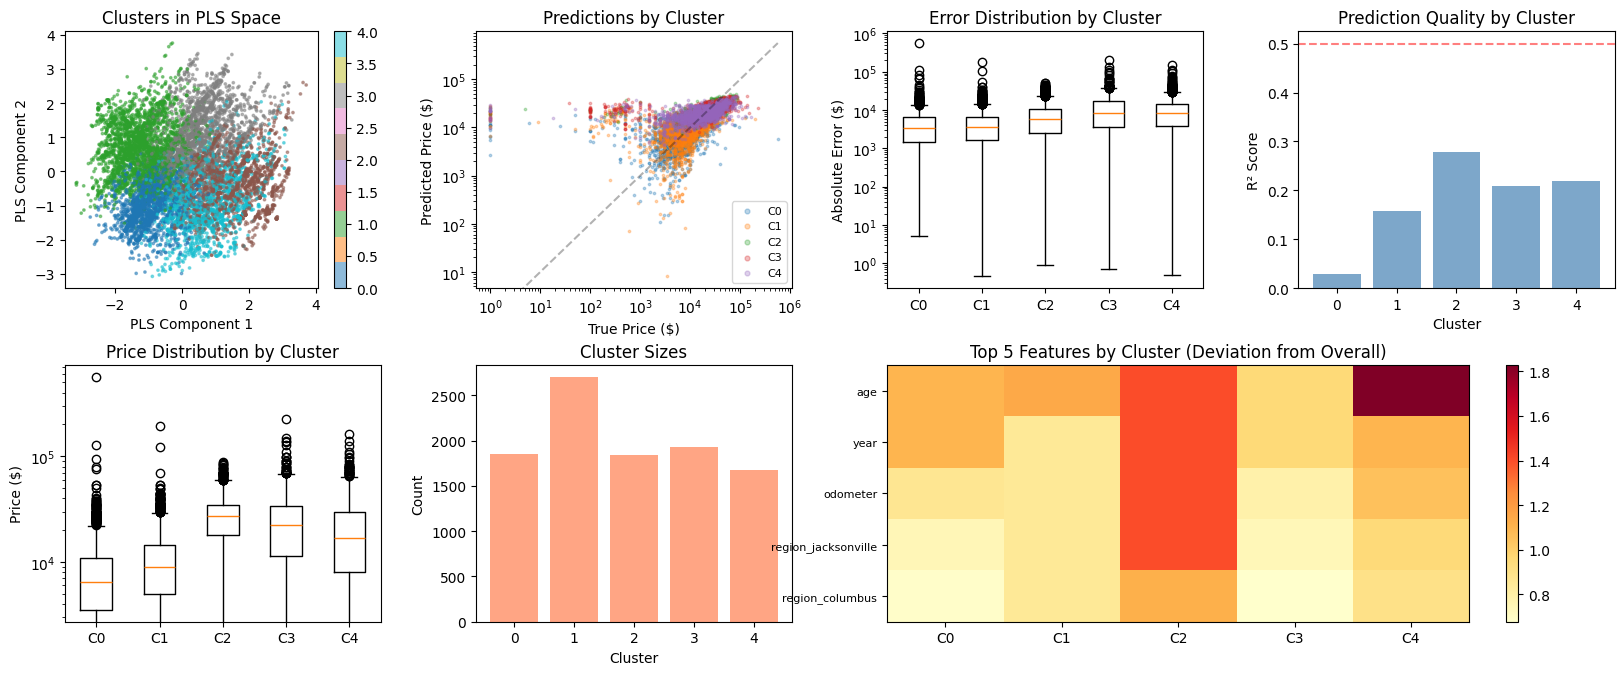


Creating integrated DataFrame...
Complete DataFrame shape: (10000, 117)

######################################################################
✓ INTEGRATED ANALYSIS COMPLETE
######################################################################
                    feature  cluster_mean  overall_mean  deviation  \
0                       age      0.766659      0.501960   1.098769   
1                      year      0.233591      0.498083  -1.098753   
2                  odometer      0.700071      0.497484   0.869093   
3       region_jacksonville      0.002172      0.008143  -0.746449   
4           region_columbus      0.013232      0.009321   0.690261   
5                type_sedan      0.709517      0.429154   0.671490   
6                       F99      0.916421      0.643024   0.650717   
7             region_eugene      0.017649      0.010508   0.648535   
8                       lat      0.571038      0.497964   0.620865   
9                      F131      0.821698      0.6024

In [53]:
# CRITICAL: Use ORIGINAL dollar prices, not scaled!
X = X_reduced_train
y_original = y_reduced_train  # NOT y_reduced_train!

# Get feature names
feature_names = feature_columns  # Your list of feature column names

# Get your trained KDS model
kds_model = kds_models[0]  # Your trained KDS model

# Run integrated analysis
results = integrated_pls_clustering(
    sparse_codes=sparse_codes,
    X_original=X,
    y_price=y_original,
    df_metadata=df_subset,
    kds_model=kds_model,
    feature_names=feature_names,
    n_pls_components=10,
    n_clusters=5,
    batch_size=500,
    price_scaler=price_scaler
)

# Access results
cluster_analysis = results['cluster_analysis']
feature_importance = results['feature_importance']
df_complete = results['df_complete']

# Save comprehensive results
cluster_analysis.to_csv('cluster_analysis.csv', index=False)
df_complete.to_csv('complete_integrated_data.csv', index=False)

# View feature importance for cluster 0
print(feature_importance[0])

# Summary statistics
print("\nCluster Summary:")
print(cluster_analysis[['cluster', 'cluster_name', 'r2', 'mae', 'median_price']])